# `global_priors.json` evaluation

We evaluate the population-level action prior on **held-out** sessions listed in `sessions_eval.txt` and `sessions_theta.txt` (their union is loaded as the test corpus here). Training rows come from `sessions_train.txt`, matching the population used to fit `artifacts/global_priors.json`.

**Session files (current layout):**

| File | Role |
|------|------|
| `sessions_train.txt` | Train — supervised rows for empirical marginals and in-distribution reference. |
| `sessions_theta.txt` | θ / EM split — sessions reserved for per-player θ estimation downstream. |
| `sessions_eval.txt` | Eval — sessions reserved for held-out metrics like this notebook. |

`split_session_names` / `sessions.txt` are no longer used for this workflow.

Supervised tensors for train + held-out are cached in `artifacts/global_priors_eval_supervised.npz`. After editing any session file or changing `POSTFLOP_EQUITY_MC`, set `FORCE_REBUILD_SUPERVISED_CACHE = True` in the data cell (or delete the npz).

Three diagnostics, each in its own cell, applied to all three heads (preflop, postflop facing-bet, postflop no-bet):

1. **Negative log-likelihood / cross-entropy** — natural metric (it *is* the training loss); we compare the trained $\beta$ to two baselines: the heuristic $\beta$ shipped in code, and the empirical marginal of actions on the train split.
2. **Brier score** — sum-of-squared errors against a one-hot label; calibration-flavored, less sensitive to overconfident wrong predictions than NLL. We use `multiclass_brier` from `utils/eval/brier.py`.
3. **Top-1 accuracy + confusion matrix** — coarse but interpretable; the confusion matrix exposes structural failure modes (e.g. "never predicts raise on the river").

## Setup

In [1]:
from __future__ import annotations

import hashlib
import json
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from runners.common import (
    flatten_hands,
    collect_preflop_supervised_rows,
    collect_postflop_supervised_rows,
    read_session_names_file,
)
from utils.action.preflop import (
    HEURISTIC_BETA_PREFLOP,
    PREFLOP_PHI_DIM,
    FOLD as PRE_FOLD,
    CHECK_CALL as PRE_CALL,
    RAISE as PRE_RAISE,
)
from utils.action.postflop import (
    HEURISTIC_BETA_FACING,
    HEURISTIC_BETA_NO_BET,
    PHI_DIM as POST_PHI_DIM,
    FOLD as POST_FOLD,
    CALL as POST_CALL,
    RAISE as POST_RAISE,
)
from utils.eval.brier import multiclass_brier

### Load the trained $\beta$ matrices

In [2]:
PRIORS_PATH = REPO_ROOT / "artifacts" / "global_priors.json"
priors = json.loads(PRIORS_PATH.read_text())

BETA_PRE      = np.asarray(priors["preflop"]["beta_preflop"],  dtype=float)   # (3, 28)
BETA_FACING   = np.asarray(priors["postflop"]["beta_facing"],  dtype=float)   # (3, 30)
BETA_NO_BET   = np.asarray(priors["postflop"]["beta_no_bet"],  dtype=float)   # (2, 30)

print("hands_used in trained file:", priors["hands_used"])
print("shapes — preflop:", BETA_PRE.shape,
      " facing:", BETA_FACING.shape,
      " no_bet:", BETA_NO_BET.shape)

hands_used in trained file: 2725
shapes — preflop: (3, 28)  facing: (3, 30)  no_bet: (2, 30)


## Load sessions and supervised rows

- **Train:** `sessions_train.txt` → `flatten_hands` → preflop/postflop supervised rows (marginals / in-sample reference).
- **Held-out (this notebook):** the union of `sessions_eval.txt` and `sessions_theta.txt` → same row collectors for `*_test` tensors.

The next code cell **loads** `artifacts/global_priors_eval_supervised.npz` when fingerprints match, otherwise **builds** it (slow). Use `FORCE_REBUILD_SUPERVISED_CACHE = True` to force a refresh.

In [3]:
PLURIBUS_ROOT = REPO_ROOT / "pluribus"
TRAIN_FILE = REPO_ROOT / "sessions_train.txt"
EVAL_FILE = REPO_ROOT / "sessions_eval.txt"
THETA_SESSIONS_FILE = REPO_ROOT / "sessions_theta.txt"

# Match runners.common.collect_postflop_supervised_rows default used at train time (or override).
POSTFLOP_EQUITY_MC = 8

CACHE_SUPERVISED = REPO_ROOT / "artifacts" / "global_priors_eval_supervised.npz"
FORCE_REBUILD_SUPERVISED_CACHE = False  # set True to re-gather rows and overwrite the npz

train_s = read_session_names_file(TRAIN_FILE)
eval_s = read_session_names_file(EVAL_FILE)
theta_s = read_session_names_file(THETA_SESSIONS_FILE)
train_inputs = [PLURIBUS_ROOT / s for s in train_s]

held_names = tuple(sorted(set(eval_s) | set(theta_s)))
held_inputs = [PLURIBUS_ROOT / s for s in held_names]

print(
    f"session lists — train: {len(train_s)} | eval: {len(eval_s)} | theta: {len(theta_s)} | held-out union: {len(held_names)}"
)

def _sha256_file(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest()


cache_meta = {
    "sessions_train_sha256": _sha256_file(TRAIN_FILE),
    "sessions_eval_sha256": _sha256_file(EVAL_FILE),
    "sessions_theta_sha256": _sha256_file(THETA_SESSIONS_FILE),
    "held_session_names_union": list(held_names),
    "postflop_equity_mc": int(POSTFLOP_EQUITY_MC),
}


def _gather_supervised(refs):
    Xpre, ypre = collect_preflop_supervised_rows(refs)
    Xf, yf, Xn, yn = collect_postflop_supervised_rows(
        refs, postflop_equity_mc=POSTFLOP_EQUITY_MC
    )
    return Xpre, ypre, Xf, yf, Xn, yn


def _cache_ok(z) -> bool:
    try:
        got = json.loads(str(z["cache_meta_json"].item()))
    except Exception:
        return False
    return got == cache_meta


loaded_from_disk = False
if CACHE_SUPERVISED.is_file() and not FORCE_REBUILD_SUPERVISED_CACHE:
    z = np.load(CACHE_SUPERVISED, allow_pickle=False)
    if _cache_ok(z):
        X_pre_train = z["X_pre_train"]
        y_pre_train = z["y_pre_train"]
        Xf_train = z["Xf_train"]
        yf_train = z["yf_train"]
        Xn_train = z["Xn_train"]
        yn_train = z["yn_train"]
        X_pre_test = z["X_pre_test"]
        y_pre_test = z["y_pre_test"]
        Xf_test = z["Xf_test"]
        yf_test = z["yf_test"]
        Xn_test = z["Xn_test"]
        yn_test = z["yn_test"]
        loaded_from_disk = True
    z.close()

if loaded_from_disk:
    print(
        f"session lists — train: {len(train_s)} | eval: {len(eval_s)} | theta: {len(theta_s)} | held-out union: {len(held_names)}"
    )
    print(f"Loaded supervised rows from {CACHE_SUPERVISED.relative_to(REPO_ROOT)}")
    print(
        f"  train: preflop n={len(y_pre_train)} | post facing={len(yf_train)} no_bet={len(yn_train)}"
    )
    print(
        f"  held-out: preflop n={len(y_pre_test)} | post facing={len(yf_test)} no_bet={len(yn_test)}"
    )
else:
    if CACHE_SUPERVISED.is_file() and not FORCE_REBUILD_SUPERVISED_CACHE:
        print("Supervised cache present but metadata mismatch — rebuilding…")
    else:
        print("Gathering supervised rows (slow; saved to npz for next run)…")
    CACHE_SUPERVISED.parent.mkdir(parents=True, exist_ok=True)
    train_refs = flatten_hands(train_inputs)
    heldout_refs = flatten_hands(held_inputs)
    print(f"train hands: {len(train_refs)} | held-out hands: {len(heldout_refs)}")
    X_pre_train, y_pre_train, Xf_train, yf_train, Xn_train, yn_train = _gather_supervised(train_refs)
    X_pre_test, y_pre_test, Xf_test, yf_test, Xn_test, yn_test = _gather_supervised(heldout_refs)
    meta_json = np.empty((), dtype=object)
    meta_json[()] = json.dumps(cache_meta, sort_keys=True)
    np.savez_compressed(
        CACHE_SUPERVISED,
        cache_meta_json=meta_json,
        X_pre_train=X_pre_train,
        y_pre_train=y_pre_train,
        Xf_train=Xf_train,
        yf_train=yf_train,
        Xn_train=Xn_train,
        yn_train=yn_train,
        X_pre_test=X_pre_test,
        y_pre_test=y_pre_test,
        Xf_test=Xf_test,
        yf_test=yf_test,
        Xn_test=Xn_test,
        yn_test=yn_test,
    )
    print(f"Wrote {CACHE_SUPERVISED.relative_to(REPO_ROOT)}")

session lists — train: 23 | eval: 10 | theta: 13 | held-out union: 23
Gathering supervised rows (slow; saved to npz for next run)…
train hands: 2725 | held-out hands: 2389
Wrote artifacts/global_priors_eval_supervised.npz


### Supervised tensors in scope

Variables `X_pre_train`, `y_pre_train`, `Xf_train`, `yf_train`, `Xn_train`, `yn_train` and the matching `*_test` arrays (built from the **union** of `sessions_eval.txt` and `sessions_theta.txt`) are produced in the previous cell (either loaded from `artifacts/global_priors_eval_supervised.npz` or computed with the same `runners.common` row collectors `train_global_priors` uses).

*(No code here — supervised tensors are assigned in the session-load cell above.)*

### Generic helpers

All three heads are softmax classifiers; we work in a uniform `(N, K)` representation where row $i$ is the predicted distribution over $K$ classes. The no-bet head's labels (`CALL=1`, `RAISE=2`) are remapped to local indices `{0, 1}` so we can use one set of helpers.

In [4]:
def softmax_rows(logits: np.ndarray) -> np.ndarray:
    m = logits.max(axis=1, keepdims=True)
    e = np.exp(logits - m)
    return e / e.sum(axis=1, keepdims=True)

def predict_probs(beta: np.ndarray, X: np.ndarray) -> np.ndarray:
    """(N, K) action distribution given (K, D) weight matrix and (N, D) features."""
    return softmax_rows(X @ beta.T)

def remap_no_bet_labels(y: np.ndarray) -> np.ndarray:
    """CALL(=1) -> 0, RAISE(=2) -> 1, matching the row order of beta_no_bet."""
    if y.size == 0:
        return y.astype(int)
    out = np.where(y == POST_CALL, 0, np.where(y == POST_RAISE, 1, -1))
    if (out == -1).any():
        bad = np.unique(y[out == -1])
        raise ValueError(f"unexpected no-bet labels: {bad}")
    return out

y_n_train_local = remap_no_bet_labels(yn_train)
y_n_test_local  = remap_no_bet_labels(yn_test)

### Baselines

For each head we compare the trained $\beta$ to:

* **Heuristic $\beta$** — the hand-coded matrices in `utils/prior/{preflop,postflop}.py`. Beating these tells us the data is adding signal beyond intuition.
* **Empirical marginal $\hat P(a)$** — the train-split action frequency. Beating this is the *floor*; if the conditional model loses to the marginal there is nothing useful in $\phi$.

In [5]:
def empirical_marginal(y: np.ndarray, n_classes: int) -> np.ndarray:
    counts = np.bincount(y.astype(int), minlength=n_classes).astype(float)
    counts = np.maximum(counts, 1e-12)   # avoid log(0)
    return counts / counts.sum()

def constant_probs(p: np.ndarray, n: int) -> np.ndarray:
    return np.broadcast_to(p, (n, p.size)).copy()

marg_pre    = empirical_marginal(y_pre_train,      n_classes=3)
marg_facing = empirical_marginal(yf_train,         n_classes=3)
marg_no_bet = empirical_marginal(y_n_train_local,  n_classes=2)

print("marginal — preflop  (fold, call, raise):", np.round(marg_pre, 3))
print("marginal — facing   (fold, call, raise):", np.round(marg_facing, 3))
print("marginal — no_bet   (call, raise):       ", np.round(marg_no_bet, 3))

marginal — preflop  (fold, call, raise): [0.714 0.11  0.176]
marginal — facing   (fold, call, raise): [0.505 0.414 0.081]
marginal — no_bet   (call, raise):        [0.679 0.321]


## 1. Negative log-likelihood / cross-entropy

$$\mathrm{NLL} = -\frac{1}{N}\sum_{i=1}^{N}\log P(a_i \mid \phi_i).$$

Lower is better. We floor probabilities at $10^{-12}$ so a hard zero on the realised action does not blow the metric to infinity.

In [6]:
EPS = 1e-12

def nll(P: np.ndarray, y: np.ndarray) -> float:
    if P.shape[0] == 0:
        return float("nan")
    p_true = np.clip(P[np.arange(P.shape[0]), y.astype(int)], EPS, 1.0)
    return float(-np.log(p_true).mean())

rows = []

# preflop ----------------------------------------------------------------
P_pre_trained   = predict_probs(BETA_PRE,             X_pre_test)
P_pre_heuristic = predict_probs(HEURISTIC_BETA_PREFLOP, X_pre_test)
P_pre_marginal  = constant_probs(marg_pre, X_pre_test.shape[0])
rows.append(("preflop", "trained",   nll(P_pre_trained,   y_pre_test)))
rows.append(("preflop", "heuristic", nll(P_pre_heuristic, y_pre_test)))
rows.append(("preflop", "marginal",  nll(P_pre_marginal,  y_pre_test)))

# postflop facing-bet ----------------------------------------------------
P_f_trained   = predict_probs(BETA_FACING,           Xf_test)
P_f_heuristic = predict_probs(HEURISTIC_BETA_FACING, Xf_test)
P_f_marginal  = constant_probs(marg_facing, Xf_test.shape[0])
rows.append(("facing", "trained",   nll(P_f_trained,   yf_test)))
rows.append(("facing", "heuristic", nll(P_f_heuristic, yf_test)))
rows.append(("facing", "marginal",  nll(P_f_marginal,  yf_test)))

# postflop no-bet --------------------------------------------------------
P_n_trained   = predict_probs(BETA_NO_BET,           Xn_test)
P_n_heuristic = predict_probs(HEURISTIC_BETA_NO_BET, Xn_test)
P_n_marginal  = constant_probs(marg_no_bet, Xn_test.shape[0])
rows.append(("no_bet", "trained",   nll(P_n_trained,   y_n_test_local)))
rows.append(("no_bet", "heuristic", nll(P_n_heuristic, y_n_test_local)))
rows.append(("no_bet", "marginal",  nll(P_n_marginal,  y_n_test_local)))

print(f"{'head':<8} {'model':<10} {'NLL':>10}")
for head, model, val in rows:
    print(f"{head:<8} {model:<10} {val:>10.4f}")

head     model             NLL
preflop  trained        0.5636
preflop  heuristic      1.0168
preflop  marginal       0.7859
facing   trained        0.7417
facing   heuristic      1.0574
facing   marginal       0.8913
no_bet   trained        0.5613
no_bet   heuristic      1.2107
no_bet   marginal       0.6284


## 2. Brier score

$$\mathrm{Brier} = \frac{1}{N}\sum_{i=1}^{N}\sum_{k=1}^{K}\big(P(a{=}k\mid\phi_i) - \mathbb{1}[a_i{=}k]\big)^2.$$

Lower is better; bounded in $[0, 2]$ for any $K$. We delegate to `utils/eval/brier.py:multiclass_brier`, which is the same scorer used elsewhere in the repo.

In [7]:
def mean_brier(P: np.ndarray, y: np.ndarray) -> float:
    if P.shape[0] == 0:
        return float("nan")
    return float(np.mean([
        multiclass_brier(P[i], int(y[i])) for i in range(P.shape[0])
    ]))

brier_rows = [
    ("preflop", "trained",   mean_brier(P_pre_trained,   y_pre_test)),
    ("preflop", "heuristic", mean_brier(P_pre_heuristic, y_pre_test)),
    ("preflop", "marginal",  mean_brier(P_pre_marginal,  y_pre_test)),
    ("facing",  "trained",   mean_brier(P_f_trained,   yf_test)),
    ("facing",  "heuristic", mean_brier(P_f_heuristic, yf_test)),
    ("facing",  "marginal",  mean_brier(P_f_marginal,  yf_test)),
    ("no_bet",  "trained",   mean_brier(P_n_trained,   y_n_test_local)),
    ("no_bet",  "heuristic", mean_brier(P_n_heuristic, y_n_test_local)),
    ("no_bet",  "marginal",  mean_brier(P_n_marginal,  y_n_test_local)),
]

print(f"{'head':<8} {'model':<10} {'Brier':>10}")
for head, model, val in brier_rows:
    print(f"{head:<8} {model:<10} {val:>10.4f}")

head     model           Brier
preflop  trained        0.3136
preflop  heuristic      0.6460
preflop  marginal       0.4449
facing   trained        0.4359
facing   heuristic      0.6404
facing   marginal       0.5569
no_bet   trained        0.3788
no_bet   heuristic      0.8485
no_bet   marginal       0.4366


## 3. Top-1 accuracy and confusion matrices

Top-1 = fraction of rows where $\arg\max_a P(a\mid\phi_i) = a_i$. We also plot the confusion matrix (rows = true class, columns = predicted class, entries = row-normalised so each row sums to 1). Diagonal-heavy = good; structural off-diagonal mass tells us where the model is systematically wrong.

In [8]:
def top1_accuracy(P: np.ndarray, y: np.ndarray) -> float:
    if P.shape[0] == 0:
        return float("nan")
    return float((P.argmax(axis=1) == y.astype(int)).mean())

def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, n_classes: int) -> np.ndarray:
    M = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true.astype(int), y_pred.astype(int)):
        M[t, p] += 1
    return M

def row_normalise(M: np.ndarray) -> np.ndarray:
    row_sums = M.sum(axis=1, keepdims=True).astype(float)
    row_sums = np.where(row_sums == 0, 1.0, row_sums)
    return M / row_sums

acc_rows = [
    ("preflop", "trained",   top1_accuracy(P_pre_trained,   y_pre_test)),
    ("preflop", "heuristic", top1_accuracy(P_pre_heuristic, y_pre_test)),
    ("preflop", "marginal",  top1_accuracy(P_pre_marginal,  y_pre_test)),
    ("facing",  "trained",   top1_accuracy(P_f_trained,   yf_test)),
    ("facing",  "heuristic", top1_accuracy(P_f_heuristic, yf_test)),
    ("facing",  "marginal",  top1_accuracy(P_f_marginal,  yf_test)),
    ("no_bet",  "trained",   top1_accuracy(P_n_trained,   y_n_test_local)),
    ("no_bet",  "heuristic", top1_accuracy(P_n_heuristic, y_n_test_local)),
    ("no_bet",  "marginal",  top1_accuracy(P_n_marginal,  y_n_test_local)),
]

print(f"{'head':<8} {'model':<10} {'top-1':>10}")
for head, model, val in acc_rows:
    print(f"{head:<8} {model:<10} {val:>10.4f}")

head     model           top-1
preflop  trained        0.7476
preflop  heuristic      0.4143
preflop  marginal       0.7159
facing   trained        0.7051
facing   heuristic      0.4421
facing   marginal       0.5147
no_bet   trained        0.7133
no_bet   heuristic      0.3461
no_bet   marginal       0.6780


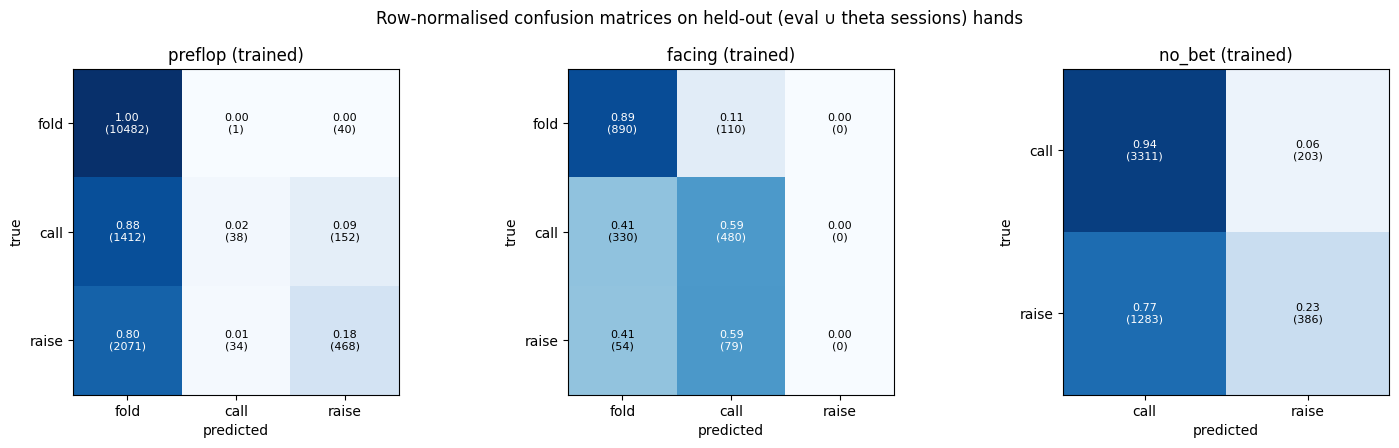

In [9]:
def plot_confusion(M: np.ndarray, labels: list[str], title: str, ax) -> None:
    Mn = row_normalise(M)
    im = ax.imshow(Mn, vmin=0.0, vmax=1.0, cmap="Blues")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f"{Mn[i, j]:.2f}\n({M[i, j]})",
                    ha="center", va="center",
                    color="white" if Mn[i, j] > 0.5 else "black",
                    fontsize=8)
    return im

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

cm_pre = confusion_matrix(y_pre_test,     P_pre_trained.argmax(axis=1), n_classes=3)
cm_f   = confusion_matrix(yf_test,        P_f_trained.argmax(axis=1),   n_classes=3)
cm_n   = confusion_matrix(y_n_test_local, P_n_trained.argmax(axis=1),   n_classes=2)

plot_confusion(cm_pre, ["fold", "call", "raise"], "preflop (trained)",  axes[0])
plot_confusion(cm_f,   ["fold", "call", "raise"], "facing (trained)",   axes[1])
plot_confusion(cm_n,   ["call", "raise"],         "no_bet (trained)",   axes[2])

fig.suptitle("Row-normalised confusion matrices on held-out (eval ∪ theta sessions) hands")
fig.tight_layout()
plt.show()

## Summary table

All three diagnostics on the held-out set, in one place.

In [10]:
summary = {}
for head, model, v in rows:        summary.setdefault((head, model), {})["NLL"]   = v
for head, model, v in brier_rows:  summary.setdefault((head, model), {})["Brier"] = v
for head, model, v in acc_rows:    summary.setdefault((head, model), {})["top-1"] = v

print(f"{'head':<8} {'model':<10} {'NLL':>8} {'Brier':>8} {'top-1':>8}")
for (head, model), vals in summary.items():
    print(f"{head:<8} {model:<10} {vals['NLL']:>8.4f} {vals['Brier']:>8.4f} {vals['top-1']:>8.4f}")

head     model           NLL    Brier    top-1
preflop  trained      0.5636   0.3136   0.7476
preflop  heuristic    1.0168   0.6460   0.4143
preflop  marginal     0.7859   0.4449   0.7159
facing   trained      0.7417   0.4359   0.7051
facing   heuristic    1.0574   0.6404   0.4421
facing   marginal     0.8913   0.5569   0.5147
no_bet   trained      0.5613   0.3788   0.7133
no_bet   heuristic    1.2107   0.8485   0.3461
no_bet   marginal     0.6284   0.4366   0.6780


### How to read the results

* **trained < heuristic < marginal** on NLL and Brier is the success case: the data-fit prior is sharper than intuition, which is sharper than the constant marginal.
* If **trained ≈ marginal**, the trained $\beta$ has not extracted information beyond the unconditional action frequency on this held-out set — likely a sample-size problem (only ~256 train hands), not a feature problem.
* If **trained < heuristic on NLL but ≈ on top-1**, the trained model is sharper in *probability* even when it picks the same modal action; that's a calibration win that the next stage (per-player $\theta$ EM) will benefit from.
* The confusion matrices flag structural failure modes — e.g. a row that lights up entirely on `call` means the model collapses to one action regardless of features, which is the most actionable finding for adding features or more data.